In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships
import matplotlib as mpl

import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import warnings

In [10]:
df_deltas = pd.read_csv("carnitines_deltas_repository.tsv", sep="\t")

In [11]:
df_deltas

,scan,delta_mass_r2,repository
0,1,-18.04,GNPS/MassIVE
1,2,-18.04,GNPS/MassIVE
2,3,-18.04,GNPS/MassIVE
3,4,-18.01,GNPS/MassIVE
4,5,-18.01,GNPS/MassIVE
...,...,...,...
34217,34218,624.51,GNPS/MassIVE
34218,34219,624.51,GNPS/MassIVE
34219,34220,624.51,GNPS/MassIVE
34220,34221,653.33,GNPS/MassIVE


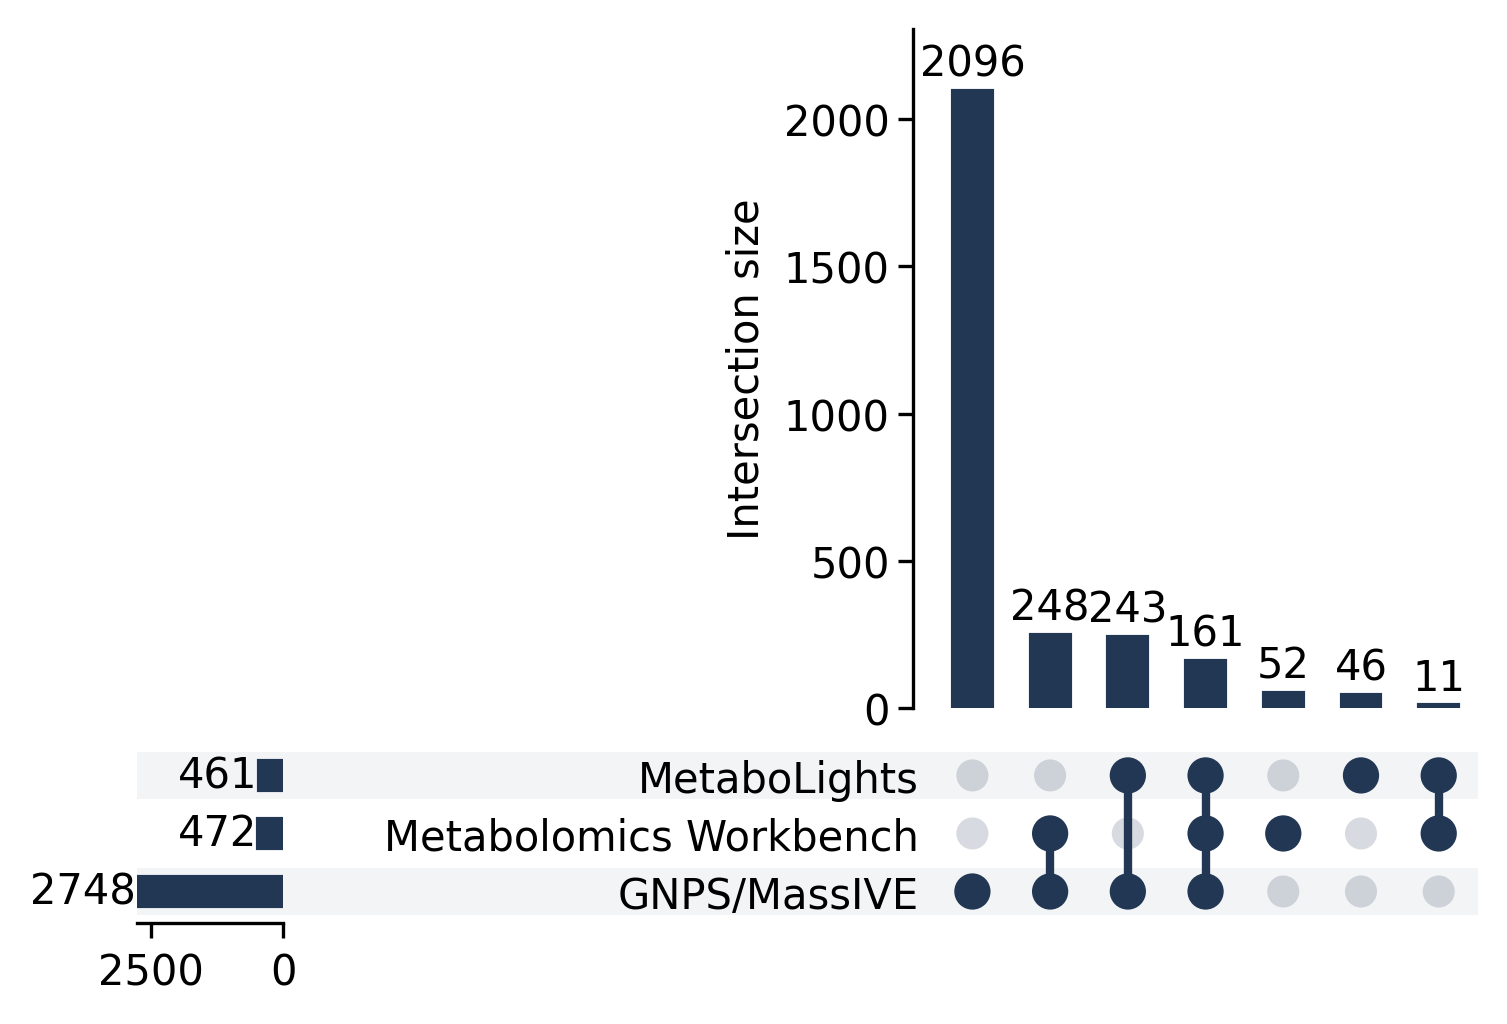

In [13]:
# Silence FutureWarnings and UserWarnings for a clean output
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# ===== Parameters =====
# Use the exact column names from your DataFrame
DELTA_COL = "delta_mass_r2"
REPO_COL = "repository"
DELTA_DECIMALS = 2  # decimal places used to define "unique deltas"

# 1. Coercion and preprocessing: prepare data for the UpSet plot
df2 = df_deltas.loc[:, [DELTA_COL, REPO_COL]].copy()
df2[DELTA_COL] = pd.to_numeric(df2[DELTA_COL], errors="coerce")
df2 = df2.dropna(subset=[DELTA_COL, REPO_COL])

# Round floats to ensure stable uniqueness
df2[DELTA_COL] = df2[DELTA_COL].round(DELTA_DECIMALS)

# Keep only unique (delta, repository) rows
X = df2.drop_duplicates()

# 2. Group deltas by repositories: create a Series with the combinations
memberships_per_delta = (
    X.groupby(DELTA_COL, sort=False)[REPO_COL]
     .apply(lambda s: tuple(sorted(set(s))))
)

# 3. Count how many times each combination appears
membership_counts = memberships_per_delta.value_counts()

# 4. Build the UpSet object from the preprocessed data
data = from_memberships(membership_counts.index, data=membership_counts.values)

# --- Aesthetics and plotting ---
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

# Increase figure size
fig = plt.figure(figsize=(10, 7), dpi=300)

up = UpSet(
    data,
    min_subset_size=1,
    element_size=22,              # smaller = shorter bars
    show_counts=True,
    sort_by="cardinality",
    intersection_plot_elements=10,
    facecolor="#223754",
)

axes = up.plot(fig=fig)

# ==== Style adjustments for the plot ====
# 1) Get the intersection bars axis
ax_bar = axes["intersections"] if isinstance(axes, dict) else plt.gca()

# 2) Offset the left spine outward
ax_bar.spines["left"].set_position(("outward", 5))
ax_bar.yaxis.set_ticks_position("left")
ax_bar.tick_params(axis="y", pad=2)

# 3) Add small lateral margin on X
ax_bar.margins(x=0.04)

# 4) Headroom at the top for labels
ymax = max((r.get_height() for r in ax_bar.patches), default=1)
ax_bar.set_ylim(0, ymax * 1.10)

# 5) Final touches
# Disable grids
for ax in (axes.values() if isinstance(axes, dict) else []):
    if hasattr(ax, "grid"):
        ax.grid(False)

plt.subplots_adjust(top=0.95, bottom=0.20, left=0.12, right=0.98)
plt.tight_layout()

# --- Output ---

# Example exports (uncomment to use)
# plt.savefig("upset_unique_deltas_by_repository.pdf", bbox_inches="tight", pad_inches=0.02)
# plt.savefig("upset_unique_deltas_by_repository.svg", bbox_inches="tight", pad_inches=0.02)

# Show and export
# plt.savefig("upset_plot_final_adjusted.png", dpi=600, bbox_inches="tight", pad_inches=0.02)
plt.savefig('upsetPlot_deltas.pdf')
plt.show()
